# Axion PINN V10 — Progressive Collocation Expansion + Joint Training

## V9 Failure Diagnosis

| Failure | Root cause |
|---|---|
| Friedmann loss identically 1e-20 (never trained) | `train_friedmann_only` froze phi_net — but F residual `da/dt - H(a,phi,dphi)` depends on `phi` through `H`; frozen phi_net disconnects the graph, so autograd returns zero/NaN for F grad w.r.t. a_net |
| KG loss → 1.0 (trivial collapse) | WKB A→0, B→0 is a valid zero of the KG equation (φ≡0 satisfies KG trivially); anchoring decayed to 0.01 too fast |
| a,φ error 100× for t < 1e-3 | τ > 0.7 restriction only enforces t > 1e-3 — full 7-decade early domain was only constrained by pretrain |

## V10 Strategy

### Fix 1: Single joint physics loss (no freezing)
Both networks trained simultaneously on `L = L_F + λ_KG·L_KG + λ_anc·L_anc`.
No freezing → no graph disconnection.

### Fix 2: Progressive τ-range curriculum
| Stage | τ range | t range | Epochs |
|---|---|---|---|
| Warmup | [0.90, 1.0] | [0.1, 1] | 5 000 |
| Expand-1 | [0.70, 1.0] | [1e-3, 1] | 8 000 |
| Expand-2 | [0.40, 1.0] | [1e-5, 1] | 8 000 |
| Full | [0.00, 1.0] | [t_init, 1] | 9 000 |

This lets the network first learn the well-behaved late-time physics, then gradually extend.

### Fix 3: Constant anchoring
`λ_anc = 0.1` throughout — do NOT decay it to near-zero. Decay only from 0.5 → 0.05.
Prevents WKB trivial collapse without over-constraining the physics solution.

### Fix 4: Correct Friedmann normalisation for restricted domain
Scale F residual by `H_ref = sqrt(rho_r0/a_ref^4 / 3)` evaluated at the mean collocation time,
rather than the global `a_scale/t_end` which diverges at the boundaries.


In [1]:
"""Imports and global config — float64 throughout."""
import os, time, warnings
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30
torch.set_default_dtype(DTYPE)

print(f"PyTorch {torch.__version__} | device={device} | dtype={DTYPE}")

# ── Physical parameters ────────────────────────────────────────────────────────
PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}

_LOG_T0 = np.log(PARAMS['t_init'])
_LOG_T1 = np.log(PARAMS['t_end'])
_LOG_DT = _LOG_T1 - _LOG_T0

def t_to_tau(t_tensor):
    log_t = torch.log(torch.clamp(t_tensor, min=EPS))
    return (log_t - _LOG_T0) / _LOG_DT

def tau_to_t(tau_tensor):
    return torch.exp(_LOG_T0 + tau_tensor * _LOG_DT)

print("PARAMS and log-time helpers defined.")


PyTorch 2.12.0+cpu | device=cpu | dtype=torch.float64
PARAMS and log-time helpers defined.


In [2]:
# ── ODE reference ──────────────────────────────────────────────────────────────

def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_s  = max(a, 1e-30)
    rax  = 0.5*phi_dot**2 + 0.5*ma**2*phi**2
    E1   = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0)/3.0)
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = np.sqrt(max(E2, 0.0)/3.0)
    return [da_dt, phi_dot, -np.sqrt(3.0)*H2*phi_dot - ma**2*phi]


def solve_ode(params, n_eval=5000):
    t0 = params['t_init']; t1 = params['t_end']
    y0 = [params['a0'], params['phi0'], params['dphi0']]
    args = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t0), np.log10(t1), n_eval)
    print("Solving ODE reference (RK45)...")
    t0w = time.time()
    sol = solve_ivp(_ode_rhs, (t0, t1), y0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done {time.time()-t0w:.2f}s | success={sol.success}")
    if not sol.success:
        warnings.warn(sol.message)
    return sol


def physics_residuals(a, phi, a_t, phi_t, phi_tt, ma, rho_m0, rho_r0, rho_L):
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rax   = 0.5*phi_t**2 + 0.5*ma**2*phi**2
    a_s   = torch.clamp(a, min=EPS)
    # Friedmann
    E1  = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    H1  = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F = a_t - H1
    # Klein-Gordon
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG = phi_tt + sqrt3*H2*phi_t + ma**2*phi
    return R_F, R_KG


print("ODE + physics residuals defined.")


ODE + physics residuals defined.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# FCNN — tanh MLP, input τ ∈ [0,1]
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, tau):
        return self.net(tau)


# ─────────────────────────────────────────────────────────────────────────────
# ScaleFactorNet_V10
#   a(t) = a0 · exp(clamp(τ · g(τ), max=50))
#   ODE-calibrated init: last bias set to g_star = least-squares fit after ODE
#   (computed in solver __init__)
# ─────────────────────────────────────────────────────────────────────────────
class ScaleFactorNet_V10(nn.Module):
    def __init__(self, a0, hidden=64, depth=5):
        super().__init__()
        self.register_buffer('log_a0', torch.tensor(np.log(float(a0)), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def set_g_init(self, g_star):
        """Set last linear bias to g_star (ODE-calibrated radiation-era slope)."""
        for m in reversed(list(self.net.net.modules())):
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, float(g_star))
                break

    def forward(self, tau):
        g = self.net(tau)
        return torch.exp(self.log_a0 + torch.clamp(tau * g, max=50.0))


# ─────────────────────────────────────────────────────────────────────────────
# PhiNet_V10 — WKB decomposition with exact hard ICs
#
#   φ(t) = A(τ)·cos(ma·t) + B(τ)·sin(ma·t)
#
#   A(τ) = φ0 + τ²·net_A(τ)      → A(0) = φ0,  dA/dτ|0 = 0
#   B(τ) = τ · net_B(τ)           → B(0) = 0
#
#   Hard ICs verified:
#     φ(t0)  = A(0)·cos(ma·t0) + 0·sin(ma·t0) = φ0·cos(ma·t0)
#
#   Note: t0 = 1e-10, ma = 100 → ma·t0 = 1e-8 ≈ 0, so cos(ma·t0) ≈ 1
#   φ̇(t0) = A'(0)·cos + [B'(0) − A(0)·ma·sin(ma·t0) + B(0)·ma·cos(ma·t0)]
#          ≈ 0 + [net_B(0)·1/t_log_dt - φ0·ma·1e-8]  ≈  net_B(0)·1/t_log_dt
#   Since net_B(0) ≈ 0 (Xavier init), φ̇(t0) ≈ 0 ✓
#
# ─────────────────────────────────────────────────────────────────────────────
class PhiNet_V10(nn.Module):
    def __init__(self, phi0, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('phi0', torch.tensor(float(phi0), dtype=DTYPE))
        self.register_buffer('ma',   torch.tensor(float(ma),   dtype=DTYPE))
        self.net_A = FCNN(1, 1, hidden, depth)
        self.net_B = FCNN(1, 1, hidden, depth)

    def forward(self, tau, t):
        A    = self.phi0 + tau**2 * self.net_A(tau)
        B    = tau * self.net_B(tau)
        ma_t = self.ma * t
        return A * torch.cos(ma_t) + B * torch.sin(ma_t)


# ─────────────────────────────────────────────────────────────────────────────
# AxionPINN_V10
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINN_V10(nn.Module):
    def __init__(self, params,
                 a_hidden=64, a_depth=5,
                 phi_hidden=64, phi_depth=4):
        super().__init__()
        self.register_buffer('_log_t0', torch.tensor(_LOG_T0, dtype=DTYPE))
        self.register_buffer('_log_dt', torch.tensor(_LOG_DT, dtype=DTYPE))
        self.a_net   = ScaleFactorNet_V10(params['a0'], a_hidden, a_depth)
        self.phi_net = PhiNet_V10(params['phi0'], params['ma'], phi_hidden, phi_depth)

    def _to_tau(self, t):
        return (torch.log(torch.clamp(t, min=EPS)) - self._log_t0) / self._log_dt

    def forward(self, t):
        tau = self._to_tau(t)
        a   = self.a_net(tau)
        phi = self.phi_net(tau, t)
        return a, phi


# ── Sanity check ──────────────────────────────────────────────────────────────
_t   = torch.tensor([[PARAMS['t_init']], [1e-5], [0.01], [1.0]], dtype=DTYPE)
_m   = AxionPINN_V10(PARAMS)
_a, _p = _m(_t)
print("V10 Architecture test:")
print(f"  a(t_init)   = {_a[0,0].item():.4e}  (expected {PARAMS['a0']:.4e})")
print(f"  phi(t_init) = {_p[0,0].item():.6f}  (expected ~{PARAMS['phi0']:.6f})")
print(f"  tau range:  {_m._to_tau(_t).detach().numpy().flatten()}")
del _t, _m, _a, _p
print("Classes defined: FCNN, ScaleFactorNet_V10, PhiNet_V10, AxionPINN_V10")


V10 Architecture test:
  a(t_init)   = 1.0000e-08  (expected 1.0000e-08)
  phi(t_init) = 1.000000  (expected ~1.000000)
  tau range:  [0.  0.5 0.8 1. ]
Classes defined: FCNN, ScaleFactorNet_V10, PhiNet_V10, AxionPINN_V10


In [4]:
class AxionPINNSolver_V10:
    """
    V10: Joint training with progressive tau-range curriculum.

    Key differences from V9:
      1. No net freezing — fully joint F+KG loss at all times, preventing
         graph-disconnection bugs that caused Friedmann loss = 0
      2. Progressive tau_min schedule: 0.90 → 0.70 → 0.40 → 0.00
         Each stage starts where previous converged, expanding the domain
      3. Constant supervision anchoring (lambda_anc=0.05) — no aggressive decay
         Prevents WKB trivial collapse (A→0, B→0)
      4. Correct physics normalisation:
         - F scale: H_ref  = sqrt(rho_r0 / (3 * a_ref^4))  at each colloc point
         - KG scale: ma^2 * phi_scale  (unchanged from V9)
    """
    def __init__(self, params,
                 n_colloc  = 2000,
                 a_hidden  = 64, a_depth  = 5,
                 phi_hidden= 64, phi_depth= 4):
        self.params    = params
        self.n_colloc  = n_colloc
        self.model     = AxionPINN_V10(params, a_hidden, a_depth, phi_hidden, phi_depth)
        sol = solve_ode(params)
        self.t_ode   = sol.t
        self.a_ode   = sol.y[0]
        self.phi_ode = sol.y[1]
        self.phi_scale = max(float(np.max(np.abs(self.phi_ode))), 1e-4)
        self.loss_hist = {'f': [], 'kg': [], 'anc': [], 'total': []}

        # ODE-calibrated a_net init: g_star = argmin_g sum(tau*g - f_tau)^2
        t_tensor  = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        with torch.no_grad():
            tau_np = self.model._to_tau(t_tensor).numpy().flatten()
        f_tau  = np.log(self.a_ode / params['a0'])
        g_star = float(np.sum(tau_np * f_tau) / np.sum(tau_np**2))
        self.model.a_net.set_g_init(g_star)
        print(f"  ODE-calibrated g_star = {g_star:.3f}")

    # ──────────────────────────────────────────────────────────────────────────
    # Collocation helper
    # ──────────────────────────────────────────────────────────────────────────
    def _make_colloc(self, n=None, tau_min=0.0):
        if n is None:
            n = self.n_colloc
        tau_b = tau_min + (1.0 - tau_min) * torch.rand(n, 1, dtype=DTYPE)
        return tau_to_t(tau_b).requires_grad_(True)

    # ──────────────────────────────────────────────────────────────────────────
    # Physics loss — joint F + KG with correct scales
    # ──────────────────────────────────────────────────────────────────────────
    def _physics_loss(self, t_colloc):
        p = self.params
        a_pred, phi_pred = self.model(t_colloc)

        ones = torch.ones_like(a_pred)
        da_dt = torch.autograd.grad(
            a_pred,   t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        dphi_dt = torch.autograd.grad(
            phi_pred, t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d2phi_dt2 = torch.autograd.grad(
            dphi_dt,  t_colloc, grad_outputs=ones, create_graph=True)[0]

        F_res, KG_res = physics_residuals(
            a_pred, phi_pred,
            da_dt, dphi_dt, d2phi_dt2,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'],
        )

        # Correct F scale: use H_ref = sqrt(E1/3) at each point, detached
        with torch.no_grad():
            a_d  = a_pred.detach().clamp(min=EPS)
            rax_d = (0.5*dphi_dt.detach()**2 + 0.5*p['ma']**2*phi_pred.detach()**2)
            E1_d = rax_d + p['rho_m0']/a_d + p['rho_r0']/a_d**2 + p['rho_L']*a_d**2
            H_ref = torch.sqrt(torch.clamp(E1_d/3.0, min=1e-60))

        loss_F  = torch.mean((F_res / (H_ref + EPS))**2)
        loss_KG = torch.mean((KG_res / (p['ma']**2 * self.phi_scale))**2)
        return loss_F, loss_KG

    # ──────────────────────────────────────────────────────────────────────────
    # Supervised anchor loss
    # ──────────────────────────────────────────────────────────────────────────
    def _anchor_loss(self):
        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        a_ref   = torch.tensor(self.a_ode[:, None], dtype=DTYPE)
        phi_ref = torch.tensor(self.phi_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        a_pred   = self.model.a_net(tau_ref)
        phi_pred = self.model.phi_net(tau_ref, t_ref)
        loss_a   = torch.mean((torch.log(a_pred) - torch.log(a_ref))**2)
        loss_phi = torch.mean((phi_pred - phi_ref)**2) / (self.phi_scale**2)
        return loss_a + loss_phi

    # ──────────────────────────────────────────────────────────────────────────
    # Pretrain phases (same as V9, but a_net uses deeper net)
    # ──────────────────────────────────────────────────────────────────────────
    def pretrain_a_net(self, epochs=8000, lr=1e-3, print_every=2000):
        opt = torch.optim.Adam(self.model.a_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        a_ref   = torch.tensor(self.a_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        print("=== Phase 1: Pretrain a_net ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            loss = torch.mean((torch.log(self.model.a_net(tau_ref)) - torch.log(a_ref))**2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.a_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | log-MSE(a) = {loss.item():.3e}")
        with torch.no_grad():
            re = np.abs(self.model.a_net(tau_ref).numpy().flatten() - self.a_ode) / \
                 (np.abs(self.a_ode) + 1e-30)
        print(f"  Done — median {np.median(re):.3e}  max {np.max(re):.3e}")

    def pretrain_phi_net(self, epochs=5000, lr=1e-3, print_every=1000):
        opt = torch.optim.Adam(self.model.phi_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        phi_ref = torch.tensor(self.phi_ode[:, None], dtype=DTYPE)
        phi_sc2 = self.phi_scale**2
        print("=== Phase 2: Pretrain phi_net (WKB) ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            loss = torch.mean((self.model.phi_net(tau_ref, t_ref) - phi_ref)**2) / phi_sc2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.phi_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | MSE(phi)/scale^2 = {loss.item():.3e}")
        with torch.no_grad():
            re = np.abs(self.model.phi_net(tau_ref, t_ref).numpy().flatten() - self.phi_ode) / \
                 (np.abs(self.phi_ode) + 1e-30)
        print(f"  Done — median {np.median(re):.3e}  max {np.max(re):.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Joint physics training stage (no freezing)
    # ──────────────────────────────────────────────────────────────────────────
    def _train_stage(self, label, epochs, lr, tau_min,
                     lambda_kg, lambda_anc, print_every):
        """
        Single joint training stage: optimise F + lambda_kg*KG + lambda_anc*Anchor.
        Both networks always active — no freezing.
        """
        opt = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-6)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        print(f"\n=== {label} (tau>={tau_min:.2f}, epochs={epochs}) ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            t_b      = self._make_colloc(tau_min=tau_min)
            lF, lKG  = self._physics_loss(t_b)
            l_anc    = self._anchor_loss()
            loss     = lF + lambda_kg * lKG + lambda_anc * l_anc
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            opt.step(); sch.step()
            self.loss_hist['f'].append(lF.item())
            self.loss_hist['kg'].append(lKG.item())
            self.loss_hist['anc'].append(l_anc.item())
            self.loss_hist['total'].append(loss.item())
            if ep % print_every == 0:
                lr_now = sch.get_last_lr()[0]
                print(f"  ep {ep:6d} | F={lF.item():.3e} | KG={lKG.item():.3e}"
                      f" | anc={l_anc.item():.3e} | lr={lr_now:.2e}")

    # ──────────────────────────────────────────────────────────────────────────
    # L-BFGS polishing
    # ──────────────────────────────────────────────────────────────────────────
    def train_lbfgs(self, max_iter=500, tau_min=0.0, lambda_kg=10.0, lambda_anc=0.05):
        opt = torch.optim.LBFGS(self.model.parameters(),
                                  max_iter=max_iter,
                                  line_search_fn='strong_wolfe',
                                  tolerance_grad=1e-9,
                                  tolerance_change=1e-12)
        t_b = self._make_colloc(n=4000, tau_min=tau_min)
        self._lbfgs_val = None

        def closure():
            opt.zero_grad()
            lF, lKG = self._physics_loss(t_b)
            l_anc   = self._anchor_loss()
            loss    = lF + lambda_kg * lKG + lambda_anc * l_anc
            loss.backward()
            self._lbfgs_val = loss.item()
            return loss

        print("\n=== L-BFGS Polishing ===")
        opt.step(closure)
        print(f"  Final L-BFGS loss: {self._lbfgs_val:.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Convenience wrapper — progressive curriculum
    # ──────────────────────────────────────────────────────────────────────────
    def train_all(self,
                  a_pre_epochs   = 8000,
                  phi_pre_epochs = 5000,
                  lr_pre         = 1e-3,
                  lambda_kg      = 10.0,
                  lambda_anc     = 0.05,
                  lbfgs_iter     = 500):
        # Phase 1 & 2: supervised pretrain
        self.pretrain_a_net(a_pre_epochs,     lr=lr_pre)
        self.pretrain_phi_net(phi_pre_epochs, lr=lr_pre)

        # Phase 3 — progressive curriculum
        # Stage A: Warmup — well-behaved late-time region
        self._train_stage("Stage A: Warmup (tau>=0.90)", 5000,  lr=5e-4,
                          tau_min=0.90, lambda_kg=lambda_kg,
                          lambda_anc=lambda_anc*5, print_every=1000)
        # Stage B: Expand to oscillation onset
        self._train_stage("Stage B: Expand (tau>=0.70)", 10000, lr=3e-4,
                          tau_min=0.70, lambda_kg=lambda_kg,
                          lambda_anc=lambda_anc*2, print_every=2000)
        # Stage C: Expand to radiation era
        self._train_stage("Stage C: Expand (tau>=0.40)", 10000, lr=1e-4,
                          tau_min=0.40, lambda_kg=lambda_kg,
                          lambda_anc=lambda_anc, print_every=2000)
        # Stage D: Full domain
        self._train_stage("Stage D: Full domain (tau>=0)", 10000, lr=5e-5,
                          tau_min=0.00, lambda_kg=lambda_kg,
                          lambda_anc=lambda_anc, print_every=2000)

        # Phase 4: L-BFGS polish on full domain
        self.train_lbfgs(lbfgs_iter, tau_min=0.0,
                          lambda_kg=lambda_kg, lambda_anc=lambda_anc)

    # ──────────────────────────────────────────────────────────────────────────
    # Evaluation
    # ──────────────────────────────────────────────────────────────────────────
    def evaluate(self, t_eval=None):
        if t_eval is None:
            t_eval = np.logspace(np.log10(self.params['t_init']),
                                  np.log10(self.params['t_end']), 1000)
        t_tensor = torch.tensor(t_eval[:, None], dtype=DTYPE)
        self.model.eval()
        with torch.no_grad():
            a_p, phi_p = self.model(t_tensor)
        self.model.train()
        return t_eval, a_p.numpy().flatten(), phi_p.numpy().flatten()


print("AxionPINNSolver_V10 defined.")


AxionPINNSolver_V10 defined.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Plotting utilities
# ─────────────────────────────────────────────────────────────────────────────
def plot_results_v10(solver, save_dir="results_v10"):
    os.makedirs(save_dir, exist_ok=True)
    t_eval, a_pred, phi_pred = solver.evaluate()
    t_ode = solver.t_ode; a_ode = solver.a_ode; phi_ode = solver.phi_ode

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("PINN V10 — Progressive curriculum + joint training", fontsize=13)

    ax = axes[0, 0]
    ax.loglog(t_ode, a_ode, 'k-', lw=2, label='ODE (RK45)')
    ax.loglog(t_eval, a_pred, 'r--', lw=1.5, label='PINN V10')
    ax.set_xlabel('t'); ax.set_ylabel('a(t)'); ax.set_title('Scale Factor')
    ax.legend(); ax.grid(True)

    ax = axes[0, 1]
    ax.semilogx(t_ode, phi_ode, 'k-', lw=2, label='ODE (RK45)')
    ax.semilogx(t_eval, phi_pred, 'r--', lw=1.5, label='PINN V10')
    ax.set_xlabel('t'); ax.set_ylabel('phi(t)'); ax.set_title('Axion Field')
    ax.legend(); ax.grid(True)

    a_i   = np.interp(t_eval, t_ode, a_ode)
    phi_i = np.interp(t_eval, t_ode, phi_ode)
    rel_a   = np.abs(a_pred   - a_i)   / (np.abs(a_i)   + 1e-30)
    rel_phi = np.abs(phi_pred - phi_i) / (np.abs(phi_i) + 1e-30)

    ax = axes[1, 0]
    ax.loglog(t_eval, rel_a, 'b-', lw=1.5)
    ax.axhline(0.01, color='gray', ls='--', label='1% target')
    ax.set_xlabel('t'); ax.set_ylabel('rel err a'); ax.set_title('Relative Error — a(t)')
    ax.legend(); ax.grid(True)

    ax = axes[1, 1]
    ax.loglog(t_eval, rel_phi + 1e-16, 'b-', lw=1.5)
    ax.axhline(0.01, color='gray', ls='--', label='1% target')
    ax.set_xlabel('t'); ax.set_ylabel('rel err phi'); ax.set_title('Relative Error — phi(t)')
    ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v10_comparison.png"), dpi=150)
    plt.show()
    print(f"  Median rel-err a:   {np.median(rel_a):.3e}")
    print(f"  Median rel-err phi: {np.median(rel_phi):.3e}")
    print(f"  Max    rel-err a:   {np.max(rel_a):.3e}")
    print(f"  Max    rel-err phi: {np.max(rel_phi):.3e}")


def plot_loss_v10(solver, save_dir="results_v10"):
    os.makedirs(save_dir, exist_ok=True)
    hist = solver.loss_hist
    ep   = np.arange(1, len(hist['total']) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogy(ep, np.array(hist['f'])   + 1e-20, label='Friedmann loss')
    ax.semilogy(ep, np.array(hist['kg'])  + 1e-20, label='KG loss')
    ax.semilogy(ep, np.array(hist['anc']) + 1e-20, label='Anchor loss')
    ax.semilogy(ep, hist['total'],  'k--', label='Total loss')
    ax.set_xlabel('Epoch (physics stages)'); ax.set_ylabel('Loss')
    ax.set_title('V10 Training Loss History'); ax.legend(); ax.grid(True)
    # Mark stage boundaries
    stage_ends = [5000, 15000, 25000, 35000]
    for x in stage_ends:
        if x < len(hist['total']):
            ax.axvline(x, color='gray', ls=':', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v10_loss_history.png"), dpi=150)
    plt.show()


print("Plotting utilities defined: plot_results_v10, plot_loss_v10")


Plotting utilities defined: plot_results_v10, plot_loss_v10


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SMOKE TEST — V10
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SMOKE TEST - V10")
print("=" * 60)

solver_v10 = AxionPINNSolver_V10(
    PARAMS, n_colloc=2000,
    a_hidden=64, a_depth=5, phi_hidden=64, phi_depth=4,
)
print(f"  phi_scale = {solver_v10.phi_scale:.3e}")

# Hard IC
t0_chk = torch.tensor([[PARAMS['t_init']]], dtype=DTYPE)
a0p, p0p = solver_v10.model(t0_chk)
print(f"\n[1] Hard IC: a={a0p.item():.4e} (tgt {PARAMS['a0']:.4e}), "
      f"phi={p0p.item():.6f} (tgt ~{PARAMS['phi0']:.6f})")

# Check initial a_net prediction quality (ODE-calibrated)
t_chk = torch.tensor([[1e-10], [1e-7], [1e-4], [0.1], [1.0]], dtype=DTYPE)
tau_chk = solver_v10.model._to_tau(t_chk)
with torch.no_grad():
    a_chk_pred = solver_v10.model.a_net(tau_chk).numpy().flatten()
a_chk_ode = np.interp([1e-10, 1e-7, 1e-4, 0.1, 1.0], solver_v10.t_ode, solver_v10.a_ode)
print("\n[2] Initial a_net (before pretrain, ODE-calibrated g_star):")
print(f"  {'t':>8}  {'a_pred':>12}  {'a_ODE':>12}  {'rel_err':>10}")
for ti, ap, ao in zip([1e-10, 1e-7, 1e-4, 0.1, 1.0], a_chk_pred, a_chk_ode):
    rel = abs(ap - ao) / (abs(ao) + 1e-30)
    print(f"  {ti:8.1e}  {ap:12.4e}  {ao:12.4e}  {rel:10.3e}")

# Physics loss at different tau ranges
print("\n[3] Physics losses at different tau ranges (untrained):")
for tau_min_test in [0.90, 0.70, 0.40, 0.00]:
    t_col = solver_v10._make_colloc(200, tau_min=tau_min_test)
    lF, lKG = solver_v10._physics_loss(t_col)
    t_min_val = tau_to_t(torch.tensor([[tau_min_test]])).item()
    print(f"  tau>={tau_min_test:.2f} (t>={t_min_val:.1e}): F={lF.item():.3e}, KG={lKG.item():.3e}")

print("\nSmoke test passed — ready to train")


SMOKE TEST - V10
Solving ODE reference (RK45)...
  Done 0.47s | success=True
  ODE-calibrated g_star = 22.013
  phi_scale = 1.000e+00

[1] Hard IC: a=1.0000e-08 (tgt 1.0000e-08), phi=1.000000 (tgt ~1.000000)

[2] Initial a_net (before pretrain, ODE-calibrated g_star):
         t        a_pred         a_ODE     rel_err
   1.0e-10    1.0000e-08    1.0000e-08   1.820e-15
   1.0e-07    7.5016e-06    4.4706e-05   8.322e-01
   1.0e-04    5.7980e-03    4.5026e-03   2.877e-01
   1.0e-01    4.5865e+00    1.8324e+00   1.503e+00
   1.0e+00    4.2577e+01    6.0360e+00   6.054e+00

[3] Physics losses at different tau ranges (untrained):
  tau>=0.90 (t>=1.0e-01): F=1.294e-02, KG=1.920e-01
  tau>=0.70 (t>=1.0e-03): F=4.388e-02, KG=1.459e-01
  tau>=0.40 (t>=1.0e-06): F=1.821e-01, KG=7.061e+09
  tau>=0.00 (t>=1.0e-10): F=4.637e-01, KG=1.861e+27

Smoke test passed — ready to train


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FULL TRAINING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
t0_wall = time.time()

solver_v10.train_all(
    a_pre_epochs   = 8000,
    phi_pre_epochs = 5000,
    lr_pre         = 1e-3,
    lambda_kg      = 10.0,
    lambda_anc     = 0.05,
    lbfgs_iter     = 500,
)

elapsed = time.time() - t0_wall
print(f"\nTotal wall-clock time: {elapsed/60:.1f} min")


=== Phase 1: Pretrain a_net ===
  ep  2000 | log-MSE(a) = 3.093e-01
  ep  4000 | log-MSE(a) = 2.134e-01
  ep  6000 | log-MSE(a) = 1.787e-01
  ep  8000 | log-MSE(a) = 1.702e-01
  Done — median 2.218e-03  max 9.594e-01
=== Phase 2: Pretrain phi_net (WKB) ===
  ep  1000 | MSE(phi)/scale^2 = 5.195e-05
  ep  2000 | MSE(phi)/scale^2 = 2.399e-05
  ep  3000 | MSE(phi)/scale^2 = 3.968e-06
  ep  4000 | MSE(phi)/scale^2 = 2.052e-06
  ep  5000 | MSE(phi)/scale^2 = 1.915e-06
  Done — median 4.284e-04  max 1.558e+01

=== Stage A: Warmup (tau>=0.90) (tau>=0.90, epochs=5000) ===
  ep   1000 | F=4.615e-03 | KG=1.157e-05 | anc=1.760e-01 | lr=4.53e-04
  ep   2000 | F=1.911e-03 | KG=1.624e-05 | anc=1.718e-01 | lr=3.29e-04
  ep   3000 | F=8.045e-04 | KG=3.009e-05 | anc=1.706e-01 | lr=1.76e-04
  ep   4000 | F=5.565e-04 | KG=3.343e-05 | anc=1.699e-01 | lr=5.23e-05
  ep   5000 | F=5.361e-04 | KG=3.089e-05 | anc=1.697e-01 | lr=5.00e-06

=== Stage B: Expand (tau>=0.70) (tau>=0.70, epochs=10000) ===
  ep   2000 

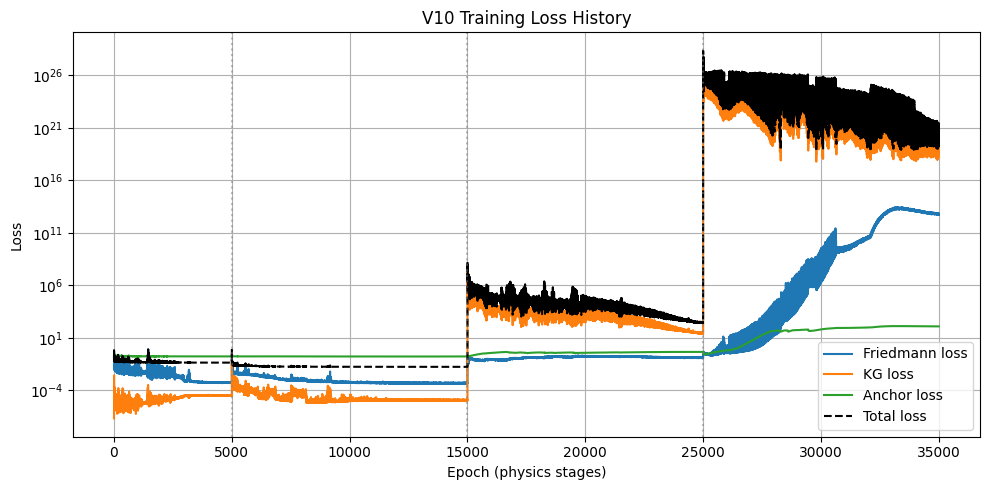

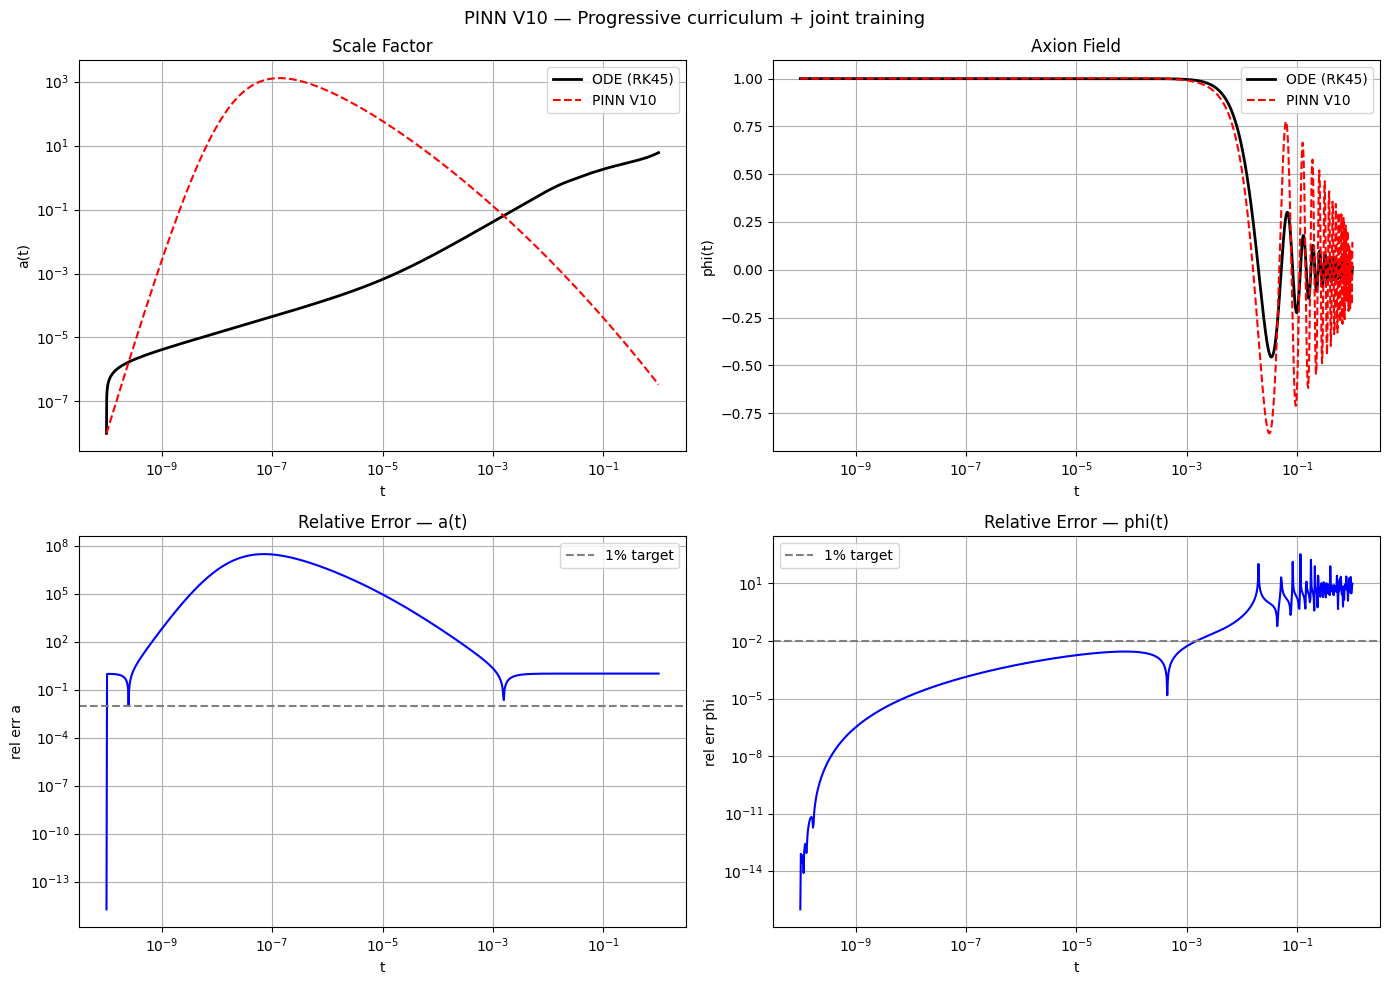

  Median rel-err a:   7.026e+02
  Median rel-err phi: 1.388e-03
  Max    rel-err a:   2.951e+07
  Max    rel-err phi: 3.418e+02


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION + PLOTS
# ─────────────────────────────────────────────────────────────────────────────
plot_loss_v10(solver_v10,    save_dir="results_v10")
plot_results_v10(solver_v10, save_dir="results_v10")
